In [35]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 

Project Title: Sales Data Analysis and Data Cleaning using Python

Objective:


Clean the sales dataset.
Identify missing values and duplicates.
Convert incorrect data types.
Detect outliers.
Analyze sales by category, region, state, and shipping mode.
Find business insights using visualization.

In [36]:
#import the data 
data = pd.read_csv("superstore_final_dataset (1).csv", encoding="latin1")

In [37]:
#show the data 
data 

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.7980
9796,9797,CA-2016-128608,12/1/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.3680
9797,9798,CA-2016-128608,12/1/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.1880
9798,9799,CA-2016-128608,12/1/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.3760


In [38]:
data.tail()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.798
9796,9797,CA-2016-128608,12/1/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.368
9797,9798,CA-2016-128608,12/1/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.188
9798,9799,CA-2016-128608,12/1/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.376
9799,9800,CA-2016-128608,12/1/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-AC-10000487,Technology,Accessories,SanDisk Cruzer 4 GB USB Flash Drive,10.384


In [39]:
data.shape

(9800, 18)

In [40]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   object 
 2   Order_Date     9800 non-null   object 
 3   Ship_Date      9800 non-null   object 
 4   Ship_Mode      9800 non-null   object 
 5   Customer_ID    9800 non-null   object 
 6   Customer_Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal_Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product_ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub_Category   9800 non-null   object 
 16  Product_Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [41]:
data.describe()

,Row_ID,Postal_Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [42]:
data.describe(include="object")

,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Region,Product_ID,Category,Sub_Category,Product_Name
count,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800
unique,4922,1230,1326,4,793,793,3,1,529,49,4,1861,3,17,1849
top,CA-2018-100111,5/9/2017,26/09/2018,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,14,38,34,5859,35,35,5101,9800,891,1946,3140,19,5909,1492,47


In [43]:
data.isnull().sum()

Row_ID            0
Order_ID          0
Order_Date        0
Ship_Date         0
Ship_Mode         0
Customer_ID       0
Customer_Name     0
Segment           0
Country           0
City              0
State             0
Postal_Code      11
Region            0
Product_ID        0
Category          0
Sub_Category      0
Product_Name      0
Sales             0
dtype: int64

In [44]:
# data.drop_duplicates(inplace=True)
data.dropna(subset=['Postal_Code'], inplace=True)

In [45]:
data.isnull().sum()

Row_ID           0
Order_ID         0
Order_Date       0
Ship_Date        0
Ship_Mode        0
Customer_ID      0
Customer_Name    0
Segment          0
Country          0
City             0
State            0
Postal_Code      0
Region           0
Product_ID       0
Category         0
Sub_Category     0
Product_Name     0
Sales            0
dtype: int64

In [46]:
data.shape

(9789, 18)

In [47]:
# Check Duplicate Rows
data.duplicated().sum()

np.int64(0)

In [48]:
data.dtypes

Row_ID             int64
Order_ID          object
Order_Date        object
Ship_Date         object
Ship_Mode         object
Customer_ID       object
Customer_Name     object
Segment           object
Country           object
City              object
State             object
Postal_Code      float64
Region            object
Product_ID        object
Category          object
Sub_Category      object
Product_Name      object
Sales            float64
dtype: object

In [49]:
data["Order_Date"] = pd.to_datetime(data["Order_Date"], dayfirst=True)

data["Ship_Date"] = pd.to_datetime(data["Ship_Date"], dayfirst=True)

In [50]:
data['Days_to_Ship'] = data['Ship_Date'] - data['Order_Date']

In [51]:
data['Year'] = data['Order_Date'].dt.year
data['Month'] = data['Order_Date'].dt.month_name()

In [52]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9789 entries, 0 to 9799
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype          
---  ------         --------------  -----          
 0   Row_ID         9789 non-null   int64          
 1   Order_ID       9789 non-null   object         
 2   Order_Date     9789 non-null   datetime64[ns] 
 3   Ship_Date      9789 non-null   datetime64[ns] 
 4   Ship_Mode      9789 non-null   object         
 5   Customer_ID    9789 non-null   object         
 6   Customer_Name  9789 non-null   object         
 7   Segment        9789 non-null   object         
 8   Country        9789 non-null   object         
 9   City           9789 non-null   object         
 10  State          9789 non-null   object         
 11  Postal_Code    9789 non-null   float64        
 12  Region         9789 non-null   object         
 13  Product_ID     9789 non-null   object         
 14  Category       9789 non-null   object         
 15  Sub_Categ

In [53]:
data

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,...,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Days_to_Ship,Year,Month
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,3 days,2017,November
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3 days,2017,November
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,4 days,2017,June
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,7 days,2016,October
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680,7 days,2016,October
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,9796,CA-2017-125920,2017-05-21,2017-05-28,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,...,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.7980,7 days,2017,May
9796,9797,CA-2016-128608,2016-01-12,2016-01-17,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,...,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.3680,5 days,2016,January
9797,9798,CA-2016-128608,2016-01-12,2016-01-17,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,...,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.1880,5 days,2016,January
9798,9799,CA-2016-128608,2016-01-12,2016-01-17,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,...,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.3760,5 days,2016,January


In [54]:
data.describe(include="object")

,Order_ID,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Region,Product_ID,Category,Sub_Category,Product_Name,Month
count,9789,9789,9789,9789,9789,9789,9789,9789,9789,9789,9789,9789,9789,9789
unique,4916,4,793,793,3,1,529,48,4,1860,3,17,1848,12
top,CA-2018-100111,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,November
freq,14,5849,35,35,5096,9789,891,1946,3140,18,5903,1492,47,1447


In [55]:
# 
for col in data.select_dtypes(include="object"):
    print(col)
    print(data[col].nunique())
    print(data[col].unique()[:10])
    print("------------------")

Order_ID
4916
['CA-2017-152156' 'CA-2017-138688' 'US-2016-108966' 'CA-2015-115812'
 'CA-2018-114412' 'CA-2017-161389' 'US-2016-118983' 'CA-2015-105893'
 'CA-2015-167164' 'CA-2015-143336']
------------------
Ship_Mode
4
['Second Class' 'Standard Class' 'First Class' 'Same Day']
------------------
Customer_ID
793
['CG-12520' 'DV-13045' 'SO-20335' 'BH-11710' 'AA-10480' 'IM-15070'
 'HP-14815' 'PK-19075' 'AG-10270' 'ZD-21925']
------------------
Customer_Name
793
['Claire Gute' 'Darrin Van Huff' 'Sean O Donnel' 'Brosina Hoffman'
 'Andrew Allen' 'Irene Maddox' 'Harold Pawlan' 'Pete Kriz'
 'Alejandro Grove' 'Zuschuss Donatelli']
------------------
Segment
3
['Consumer' 'Corporate' 'Home Office']
------------------
Country
1
['United States']
------------------
City
529
['Henderson' 'Los Angeles' 'Fort Lauderdale' 'Concord' 'Seattle'
 'Fort Worth' 'Madison' 'West Jordan' 'San Francisco' 'Fremont']
------------------
State
48
['Kentucky' 'California' 'Florida' 'North Carolina' 'Washington' 'Tex

In [56]:
data.describe()

,Row_ID,Order_Date,Ship_Date,Postal_Code,Sales,Days_to_Ship,Year
count,9789.000000,9789,9789,9789.000000,9789.000000,9789,9789.000000
mean,4896.705588,2017-05-01 02:51:57.866993664,2017-05-05 01:56:03.898253056,55273.322403,230.116193,3 days 23:04:06.031259577,2016.723567
min,1.000000,2015-01-03 00:00:00,2015-01-07 00:00:00,1040.000000,0.444000,0 days 00:00:00,2015.000000
25%,2449.000000,2016-05-23 00:00:00,2016-05-27 00:00:00,23223.000000,17.248000,3 days 00:00:00,2016.000000
50%,4896.000000,2017-06-26 00:00:00,2017-06-29 00:00:00,58103.000000,54.384000,4 days 00:00:00,2017.000000
75%,7344.000000,2018-05-15 00:00:00,2018-05-19 00:00:00,90008.000000,210.392000,5 days 00:00:00,2018.000000
max,9800.000000,2018-12-30 00:00:00,2019-01-05 00:00:00,99301.000000,22638.480000,7 days 00:00:00,2018.000000
std,2827.486899,NaN,NaN,32041.223413,625.302079,1 days 18:00:39.083391657,1.124184


In [57]:
numeric = data.select_dtypes(include=np.number)

numeric.columns

Index(['Row_ID', 'Postal_Code', 'Sales', 'Days_to_Ship', 'Year'], dtype='object')

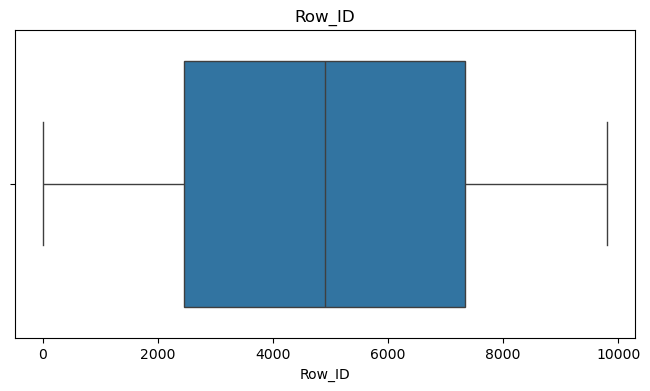

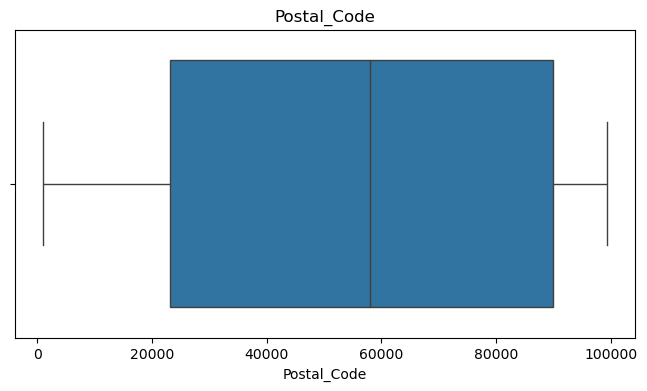

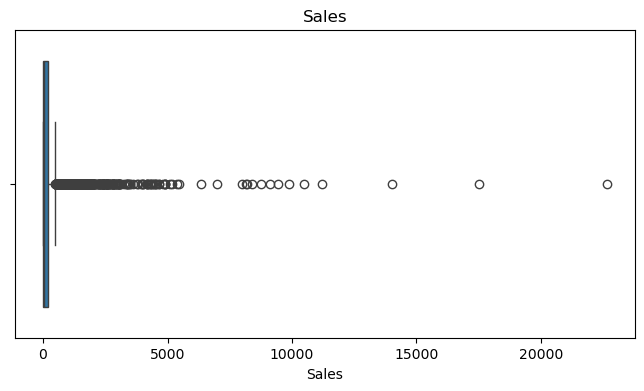

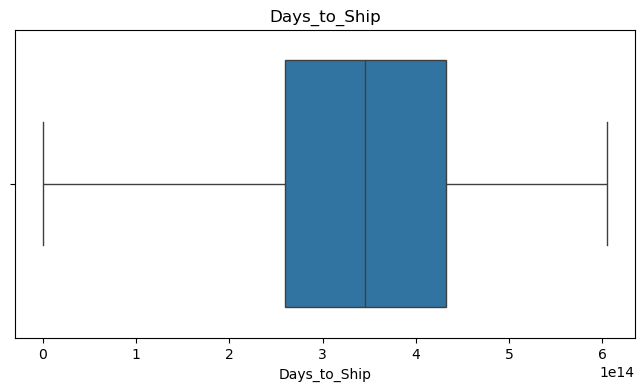

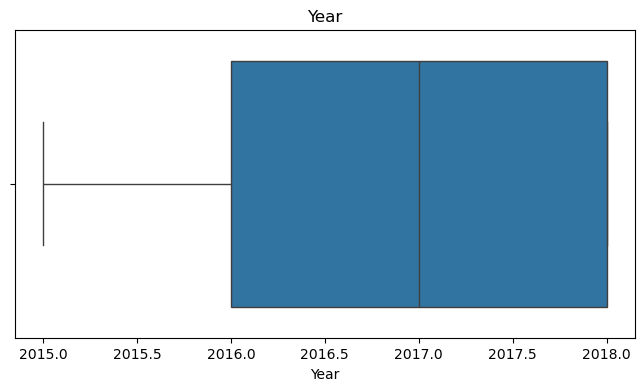

In [58]:
for col in numeric.columns:

    plt.figure(figsize=(8,4))

    sns.boxplot(x=data[col])

    plt.title(col)

    plt.show()

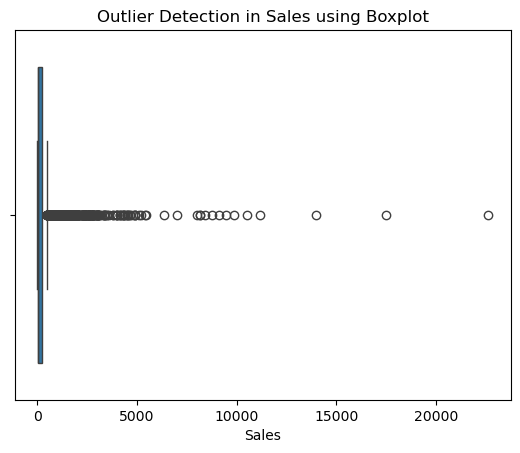

In [59]:
# Plotting a boxplot for Sales to see outliers
sns.boxplot(x=data['Sales'])
plt.title('Outlier Detection in Sales using Boxplot')
plt.show()

In [60]:
# Step 1: Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = data['Sales'].quantile(0.25)
Q3 = data['Sales'].quantile(0.75)

# Step 2: Calculate IQR
IQR = Q3 - Q1

# Step 3: Define Upper and Lower bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower Bound for Sales: {lower_bound}")
print(f"Upper Bound for Sales: {upper_bound}")

# Step 4: Find the outliers
outliers = data[(data['Sales'] < lower_bound) | (data['Sales'] > upper_bound)]
print(f"Total number of outliers in Sales: {len(outliers)}")

Lower Bound for Sales: -272.468
Upper Bound for Sales: 500.108
Total number of outliers in Sales: 1141


In [61]:
# Filter and view the rows that are outliers
sales_outliers = data[data['Sales'] > upper_bound]
print(sales_outliers[['Customer_Name', 'Category', 'Product_Name', 'Sales']].head())

      Customer_Name    Category  \
1       Claire Gute   Furniture   
3     Sean O Donnel   Furniture   
7   Brosina Hoffman  Technology   
10  Brosina Hoffman   Furniture   
11  Brosina Hoffman  Technology   

                                         Product_Name      Sales  
1   Hon Deluxe Fabric Upholstered Stacking Chairs,...   731.9400  
3       Bretford CR4500 Series Slim Rectangular Table   957.5775  
7                      Mitel 5320 IP Phone VoIP phone   907.1520  
10           Chromcraft Rectangular Conference Tables  1706.1840  
11      Konftel 250 Conference phone - Charcoal black   911.4240  


In [62]:
# Dataset without outliers (for general customer behavior analysis)
data_normal = data[data['Sales'] <= upper_bound]

# Dataset with only outliers (for high-value VIP customer analysis)
data_vip = data[data['Sales'] > upper_bound]

print(f"Normal Sales Average: ${data_normal['Sales'].mean():.2f}")
print(f"VIP Sales Average: ${data_vip['Sales'].mean():.2f}")

Normal Sales Average: $93.18
VIP Sales Average: $1267.97


In [63]:
# Import numpy for conditional replacement
import numpy as np

# Apply Capping and Flooring using IQR bounds
# If Sales is greater than upper_bound, replace it with upper_bound
# If Sales is less than lower_bound, replace it with lower_bound
data['Sales_Cleaned'] = np.where(data['Sales'] > upper_bound, upper_bound, 
                                 np.where(data['Sales'] < lower_bound, lower_bound, data['Sales']))

# Verify that there are no more outliers in the new column
new_outliers = data[(data['Sales_Cleaned'] < lower_bound) | (data['Sales_Cleaned'] > upper_bound)]
print(f"Total number of outliers in Sales_Cleaned: {len(new_outliers)}")

Total number of outliers in Sales_Cleaned: 0


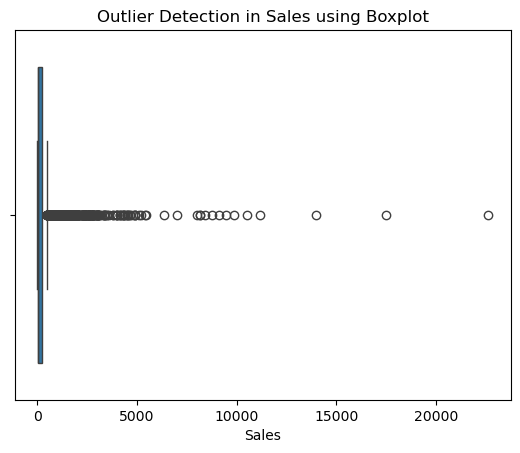

In [64]:
# Plotting a boxplot for Sales to see outliers
sns.boxplot(x=data['Sales'])
plt.title('Outlier Detection in Sales using Boxplot')
plt.show()

In [65]:
# Compare original Sales and Cleaned Sales for high-value rows
# This will show you exactly how outliers were capped
outlier_comparison = data[data['Sales'] > 500.11][['Customer_Name', 'Sales', 'Sales_Cleaned']].head()
print(outlier_comparison)

      Customer_Name      Sales  Sales_Cleaned
1       Claire Gute   731.9400        500.108
3     Sean O Donnel   957.5775        500.108
7   Brosina Hoffman   907.1520        500.108
10  Brosina Hoffman  1706.1840        500.108
11  Brosina Hoffman   911.4240        500.108


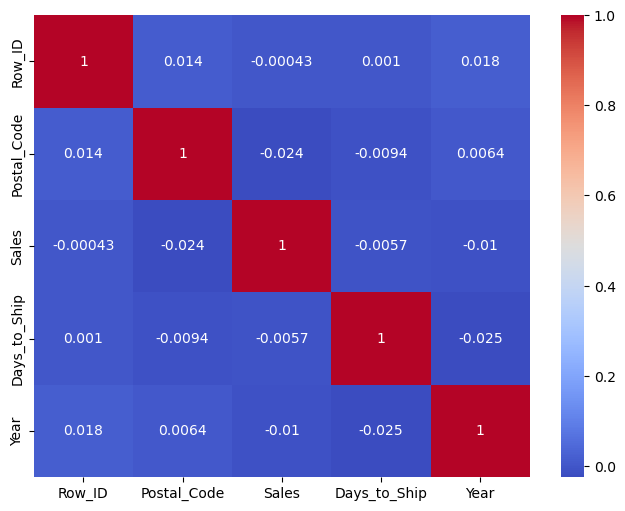

In [66]:
plt.figure(figsize=(8,6))

sns.heatmap(numeric.corr(), annot=True, cmap="coolwarm")

plt.show()

In [67]:
# Select only numerical columns for correlation
numerical_data = data[['Sales', 'Days_to_Ship_Num', 'Postal_Code']]

# Calculate correlation matrix
correlation_matrix = numerical_data.corr()
print(correlation_matrix)

KeyError: "['Days_to_Ship_Num'] not in index"

In [68]:


# Plotting the correlation heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Data')
plt.show()

NameError: name 'correlation_matrix' is not defined

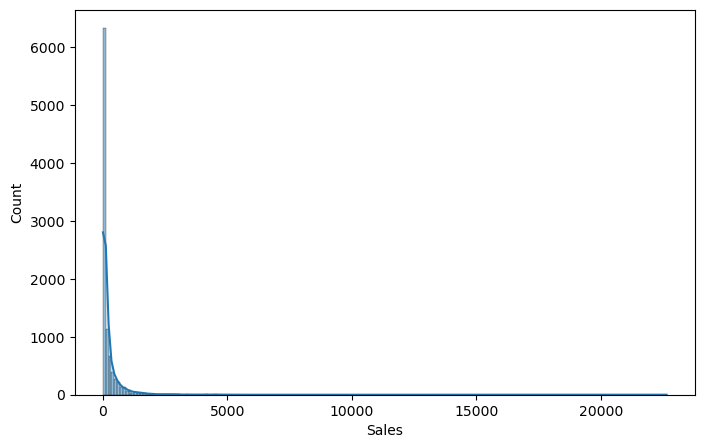

In [69]:
plt.figure(figsize=(8,5))

sns.histplot(data["Sales"], kde=True) #Kernel Density Estimation

plt.show()

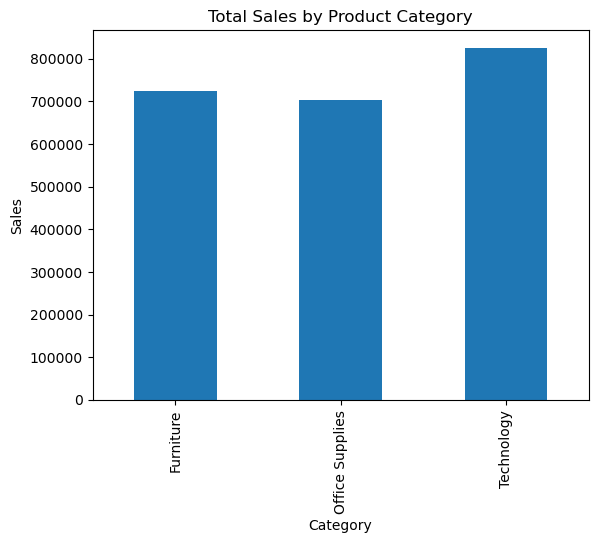

In [ ]:
#Category-wise Sales
category_sales = data.groupby("Category")["Sales"].sum()

category_sales.plot(kind="bar")

plt.ylabel("Sales")  #(Y-axis / vertical axis)
plt.title("Total Sales by Product Category")

plt.show()

Category
Furniture          723538.4757
Office Supplies    703212.8240
Technology         825856.1130
Name: Sales, dtype: float64


<Axes: title={'center': 'Sales Share by Category'}, ylabel='Sales'>

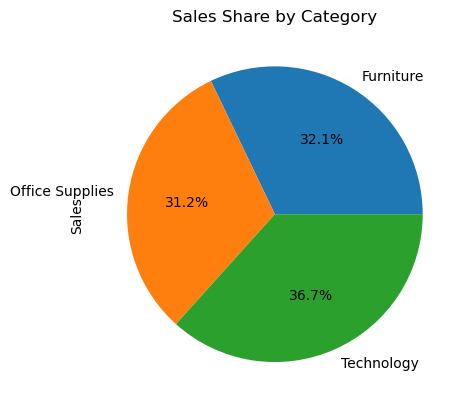

In [ ]:
# Group by 'Category' and calculate total sales
category_sales = data.groupby('Category')['Sales'].sum()
print(category_sales)

# Optional: Plot a pie chart to see the percentage share
category_sales.plot(kind='pie', autopct='%1.1f%%', title='Sales Share by Category')

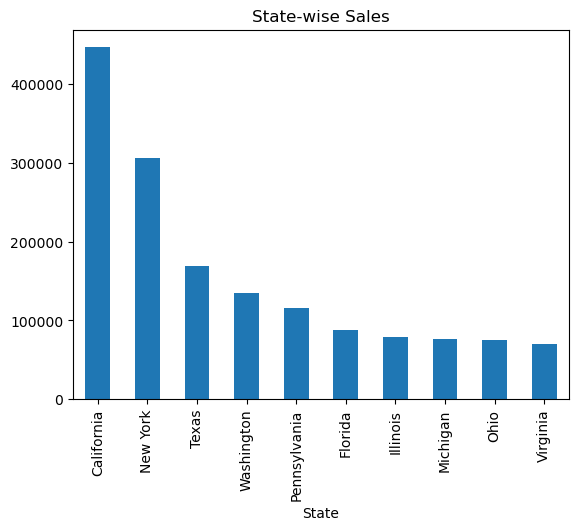

In [ ]:
state_sales = data.groupby("State")["Sales"].sum().sort_values(ascending=False)

state_sales.head(10).plot(kind="bar")
plt.title('State-wise Sales')

plt.show()

C:\Users\asus\AppData\Local\Temp\ipykernel_23876\1065006381.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x="Segment", y="Sales", palette="Set2")


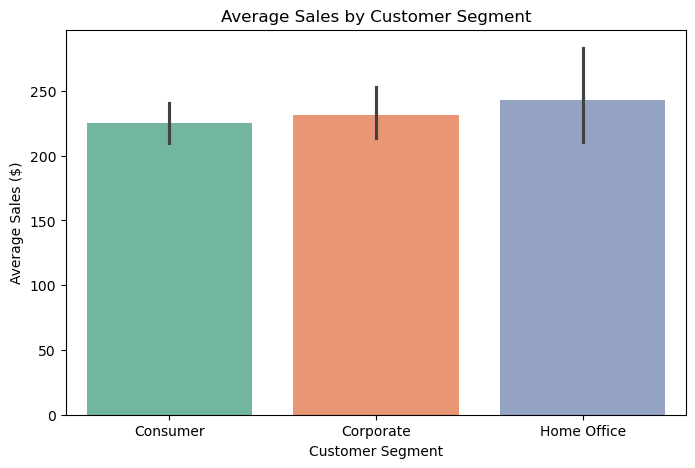

In [ ]:
# Set the figure size
plt.figure(figsize=(8, 5))

# Create the bar plot showing average sales per segment
sns.barplot(data=data, x="Segment", y="Sales", palette="Set2")

# Add Labels and Title
plt.xlabel("Customer Segment")
plt.ylabel("Average Sales ($)")
plt.title("Average Sales by Customer Segment")

# Display the plot
plt.show()

जब तपाईं यो ग्राफ चलाउनुहुन्छ, प्रत्येक टावर वा खम्बाको ठीक माथि एउटा सानो कालो धर्को (एकदमै सानो "I" आकारको रेखा) देखिनेछ। यसलाई डेटा साइन्समा Error Bar वा Confidence Interval भनिन्छ।

In [ ]:
data

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,...,Product_ID,Category,Sub_Category,Product_Name,Sales,Days_to_Ship,Year,Month,Days_to_Ship_Num,Sales_Cleaned
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,3 days,2017,November,3,261.960
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3 days,2017,November,3,500.108
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,4 days,2017,June,4,14.620
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,7 days,2016,October,7,500.108
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680,7 days,2016,October,7,22.368
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,9796,CA-2017-125920,2017-05-21,2017-05-28,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,...,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.7980,7 days,2017,May,7,3.798
9796,9797,CA-2016-128608,2016-01-12,2016-01-17,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,...,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.3680,5 days,2016,January,5,10.368
9797,9798,CA-2016-128608,2016-01-12,2016-01-17,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,...,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.1880,5 days,2016,January,5,235.188
9798,9799,CA-2016-128608,2016-01-12,2016-01-17,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,...,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.3760,5 days,2016,January,5,26.376


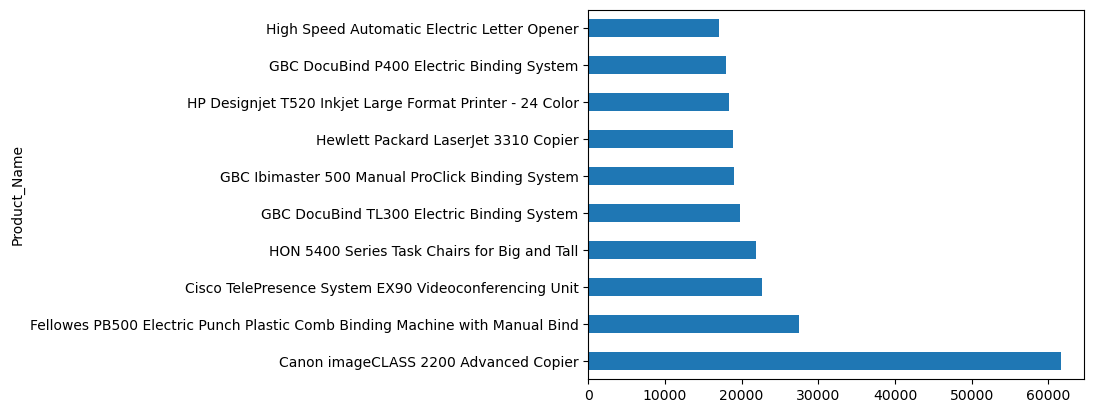

In [ ]:
#Top 10 Products
top = data.groupby("Product_Name")["Sales"].sum()

top.sort_values(ascending=False).head(10).plot(kind="barh")

plt.show()

<Axes: title={'center': 'Total Sales by Year'}, xlabel='Year'>

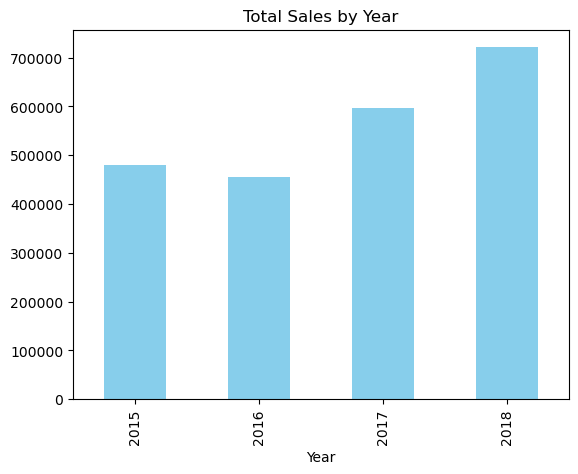

In [ ]:
#Yearly Sales
data.groupby('Year')['Sales'].sum().plot(kind='bar', color='skyblue',title='Total Sales by Year')

Year
2015    479856.2081
2016    454315.9054
2017    597225.4900
2018    721209.8092
Name: Sales, dtype: float64


<Axes: title={'center': 'Total Sales by Year'}, xlabel='Year'>

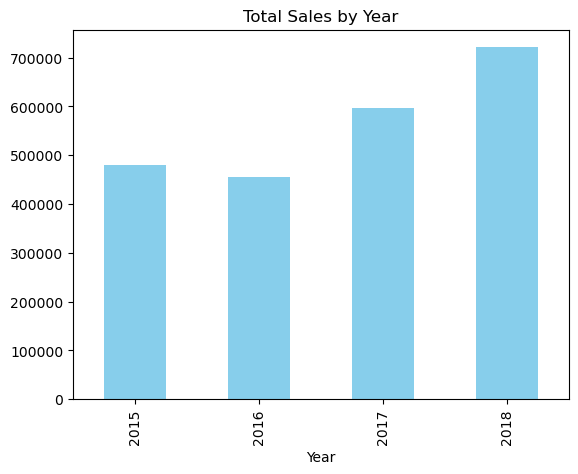

In [ ]:
# Group by 'Year' and calculate total sales
yearly_sales = data.groupby('Year')['Sales'].sum()
print(yearly_sales)

# Optional: Plot the yearly sales trend
yearly_sales.plot(kind='bar', color='skyblue', title='Total Sales by Year')

In [ ]:
# Extract the number of days as an integer
data['Days_to_Ship_Num'] = data['Days_to_Ship'].dt.days

# Calculate the average shipping time
avg_shipping_time = data['Days_to_Ship_Num'].mean()
print(f"Average Shipping Time: {avg_shipping_time:.2f} days")

Average Shipping Time: 3.96 days


In [ ]:
# Group by 'Month' and sum the sales, sorted from highest to lowest
monthly_sales = data.groupby('Month')['Sales'].sum().sort_values(ascending=False)
print(monthly_sales)

Month
November     345041.6110
December     321275.1395
September    300103.4117
October      199496.2947
March        197573.5872
August       157315.9270
May          154086.7237
June         145837.5233
July         145535.6890
April        134988.2506
January       91982.1396
February      59371.1154
Name: Sales, dtype: float64


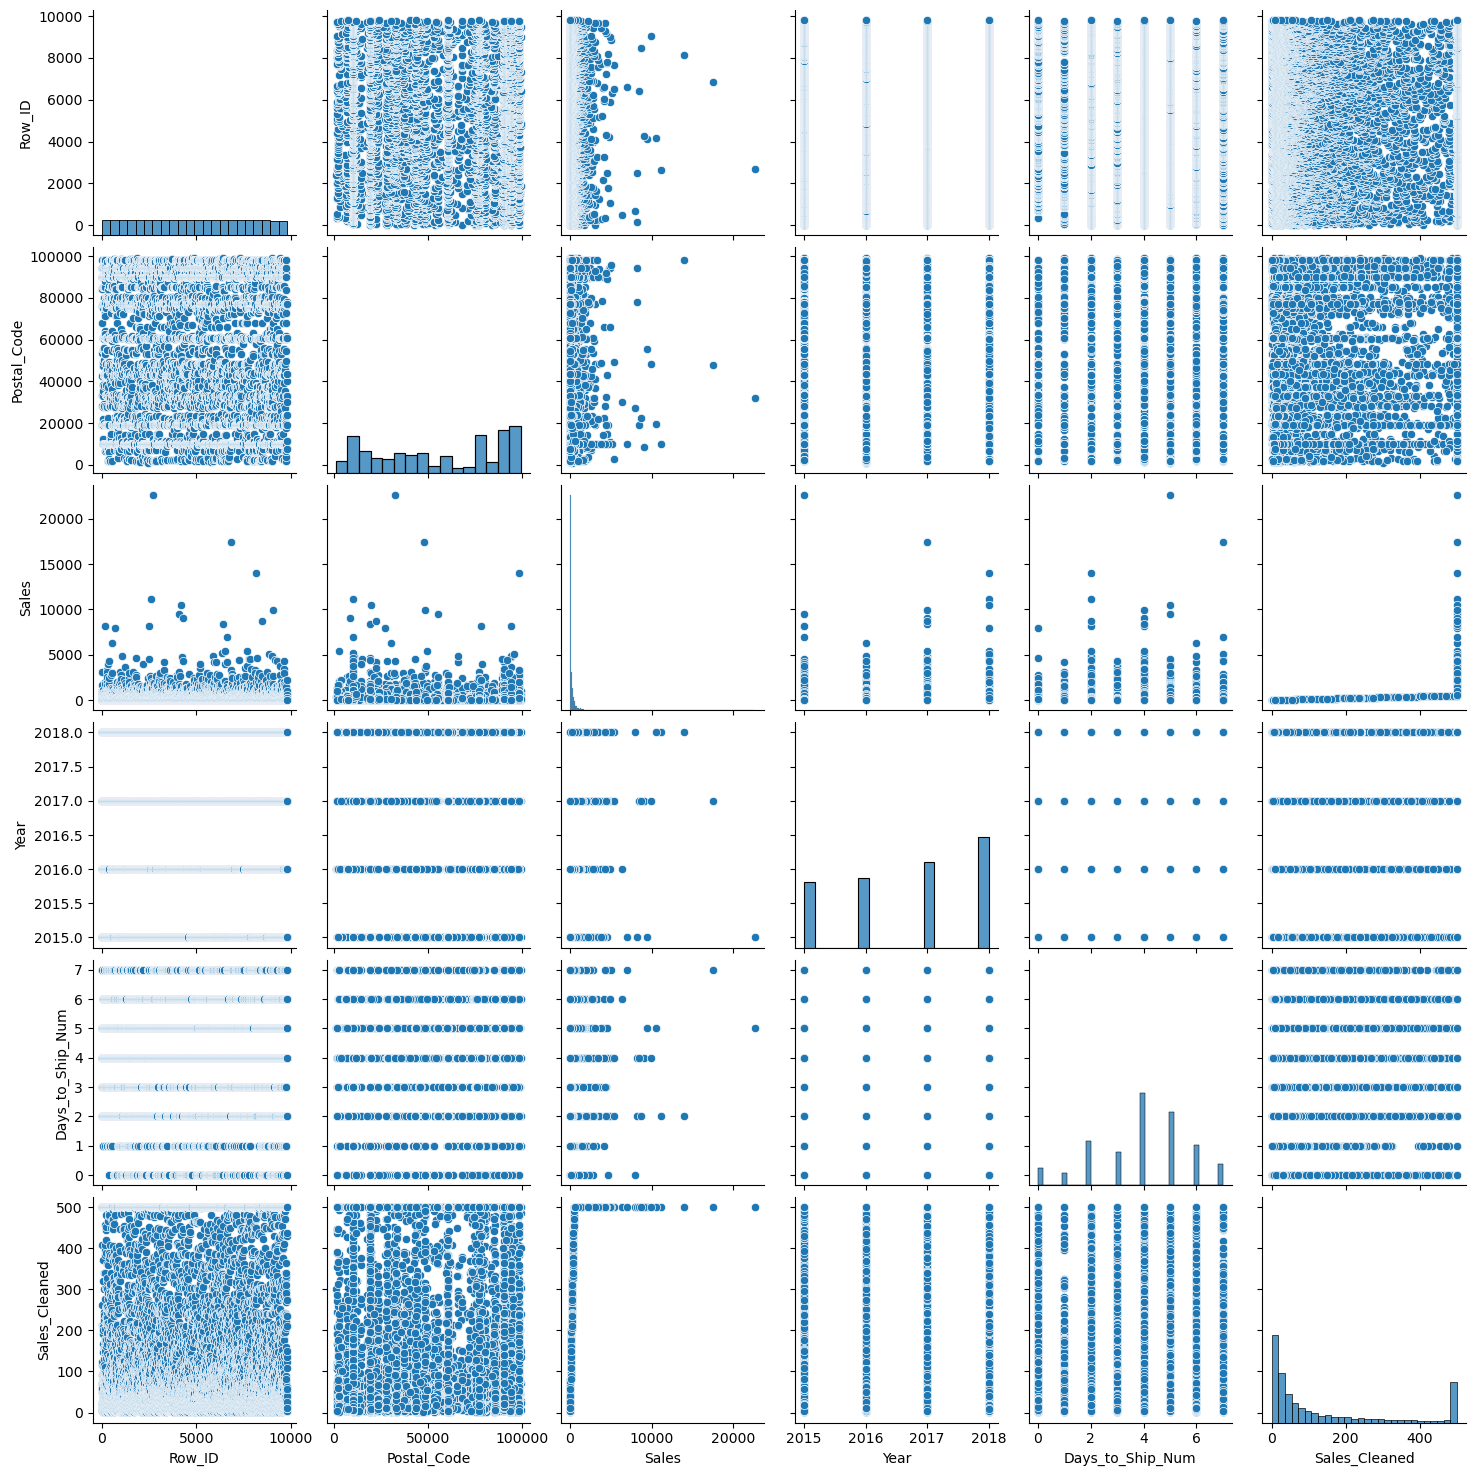

In [ ]:
sns.pairplot(data.select_dtypes(include=np.number))

plt.show()

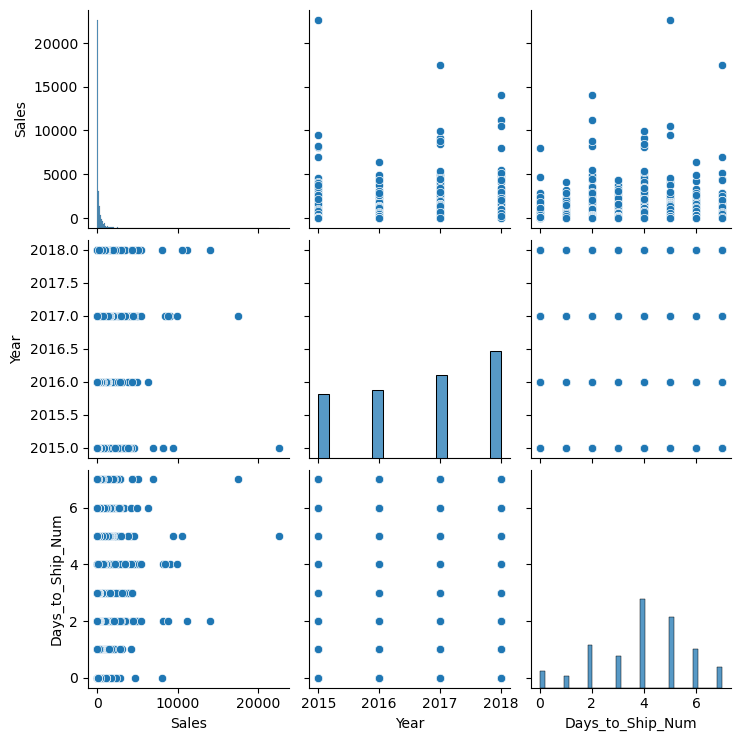

In [ ]:


# केवल मुख्य ३ वटा नम्बर कोलमहरू मात्र छान्ने (Making it simple)
simple_data = data[['Sales', 'Year', 'Days_to_Ship_Num']]

# सिम्पल पेयरप्लटका लागि कोड (Simple Pairplot)
sns.pairplot(simple_data)

# ग्राफ देखाउने
plt.show()

In [ ]:
data.to_csv("clean_superstore.csv", index=False)